### Predictive Modeling

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from sklearn.preprocessing import OneHotEncoder

In [51]:
# load the data
cars = pd.read_csv(r'C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\datasets\cars_analyzed.csv')
cars.head()

,Make,Model,Year,Mileage,Condition,Price,Age,Mileage_Segment,Year_Bracket
0,Ford,Silverado,2022,18107,Excellent,19094.75,4,Low (< 30k),2019-2023
1,Toyota,Silverado,2014,13578,Excellent,27321.10,12,Low (< 30k),2013-2015
2,Chevrolet,Civic,2016,46054,Good,23697.30,10,Medium (30k–70k),2016-2018
3,Ford,Civic,2022,34981,Excellent,18251.05,4,Medium (30k–70k),2019-2023
4,Chevrolet,Civic,2019,63565,Excellent,19821.85,7,Medium (30k–70k),2019-2023


In [52]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Make             1000 non-null   object 
 1   Model            1000 non-null   object 
 2   Year             1000 non-null   int64  
 3   Mileage          1000 non-null   int64  
 4   Condition        1000 non-null   object 
 5   Price            1000 non-null   float64
 6   Age              1000 non-null   int64  
 7   Mileage_Segment  1000 non-null   object 
 8   Year_Bracket     1000 non-null   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 70.4+ KB


In [53]:
cars.columns

Index(['Make', 'Model', 'Year', 'Mileage', 'Condition', 'Price', 'Age',
       'Mileage_Segment', 'Year_Bracket'],
      dtype='object')

### Feature Engineering

In [54]:
# Mileage per year 
# Mileage per year is a useful feature to understand how much a car has been driven on average each year. It can help us identify cars that have been driven more or less than average, which can be an important factor in determining the car's value and condition.
cars['Mileage_per_year'] = cars['Mileage'] / cars['Age'].clip(lower=1)  # Avoid division by zero for new cars

In [55]:
# Usage level
# We can categorize cars into different usage levels based on their mileage per year. This can help us understand how much a car has been driven and can be an important factor in determining its value and condition.
def categorize_usage(mileage_per_year):
    if mileage_per_year < 10000:
        return 'Low'
    elif mileage_per_year < 15000:
        return 'Medium'
    else:
        return 'High'

cars['Usage_Level'] = cars['Mileage_per_year'].apply(categorize_usage)

In [56]:
#Make and model combined
# Combining the 'Make' and 'Model' columns into a single 'Make_Model' column can be useful for predictive modeling, as it allows us to capture the specific make and model of each car as a single feature. This can help improve the accuracy of our models by providing more detailed information about the cars in our dataset.
cars['Make_Model'] = cars['Make'] + ' ' + cars['Model']

In [57]:
cars.head()

,Make,Model,Year,Mileage,Condition,Price,Age,Mileage_Segment,Year_Bracket,Mileage_per_year,Usage_Level,Make_Model
0,Ford,Silverado,2022,18107,Excellent,19094.75,4,Low (< 30k),2019-2023,4526.750000,Low,Ford Silverado
1,Toyota,Silverado,2014,13578,Excellent,27321.10,12,Low (< 30k),2013-2015,1131.500000,Low,Toyota Silverado
2,Chevrolet,Civic,2016,46054,Good,23697.30,10,Medium (30k–70k),2016-2018,4605.400000,Low,Chevrolet Civic
3,Ford,Civic,2022,34981,Excellent,18251.05,4,Medium (30k–70k),2019-2023,8745.250000,Low,Ford Civic
4,Chevrolet,Civic,2019,63565,Excellent,19821.85,7,Medium (30k–70k),2019-2023,9080.714286,Low,Chevrolet Civic


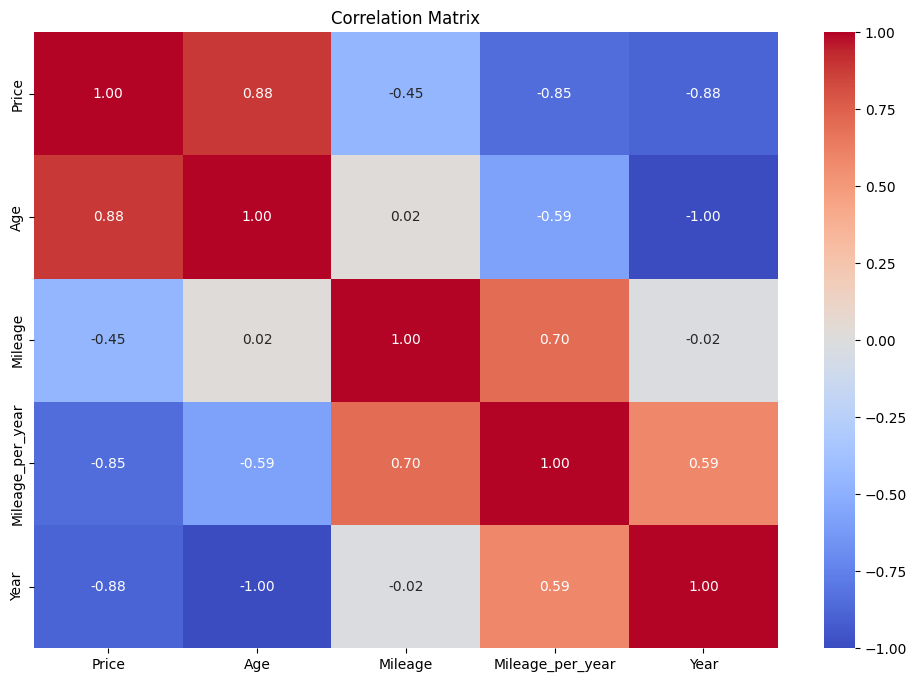

In [58]:
# correlation matrix
correlation_matrix = cars[['Price', 'Age', 'Mileage', 'Mileage_per_year', 'Year']].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


### Feature Encoding

##### Label Encoder for tree based models

In [59]:
# seperate into different independent and dependent variables (carsX and carsY)
# droping the Age column as it is highly correlated with the Year column and can cause multicollinearity issues in our models. By dropping the Age column, we can reduce the risk of multicollinearity and improve the performance of our models.
carsX = cars.drop(columns=['Price','Age'])
carsY = cars['Price']

In [60]:
# Make copy of carsX to perform encoding and scaling on it
carsX_encoded_scaled = carsX.copy()

In [61]:
# Select categorical columns for encoding
categorical_cols = carsX_encoded_scaled.select_dtypes(include=['object']).columns.tolist()

In [62]:
# Encoding categorical variables
le = LabelEncoder()
for col in categorical_cols:
    carsX_encoded_scaled[col] = le.fit_transform(carsX_encoded_scaled[col])

##### One - Hot Encoding for Linear Regression Model

In [63]:
# One-hot encoding for categorical variables
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False) 

In [64]:
# Fit and transform on the training data
carsX_oh = encoder.fit_transform(carsX[categorical_cols])

### Train - Test split

In [65]:
# Split the data into training and testing sets using 80% to 20% for tree based models
X_train, X_test, y_train, y_test = train_test_split(carsX_encoded_scaled, carsY, test_size=0.2, random_state=42)

In [66]:
# Split the data into training and testing sets using 80% to 20% for linear regression model
X_train_oh,X_test_oh, y_train_oh,y_test_oh = train_test_split(carsX_oh, carsY, test_size=0.2, random_state=42)

### Feature Scaling

In [67]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test) 

In [68]:
scaler_oh = StandardScaler()
X_train_oh = scaler_oh.fit_transform(X_train_oh)
X_test_oh  = scaler_oh.transform(X_test_oh)

### Training Models
- Random forest
- Decision Tree
- XGBoost
- Linear regression

In [69]:
# creating all instances of the models
linreg = LinearRegression()
tree_reg = DecisionTreeRegressor(random_state=42)
forest_reg = RandomForestRegressor(random_state=42)
xgb_reg = XGBRegressor(random_state=42)

In [70]:
# cross validation scores for all the models
linreg_cv_scores = cross_val_score(linreg, X_train_oh, y_train_oh, cv=5, scoring='r2')
tree_reg_cv_scores = cross_val_score(tree_reg, X_train, y_train, cv=5, scoring='r2')
forest_reg_cv_scores = cross_val_score(forest_reg, X_train, y_train, cv=5, scoring='r2')
xgb_reg_cv_scores = cross_val_score(xgb_reg, X_train, y_train, cv=5, scoring='r2')

print("Linear Regression CV Scores:", linreg_cv_scores)
print("Decision Tree Regressor CV Scores:", tree_reg_cv_scores)
print("Random Forest Regressor CV Scores:", forest_reg_cv_scores)
print("XGBoost Regressor CV Scores:", xgb_reg_cv_scores)

Linear Regression CV Scores: [0.92401497 0.95115613 0.94379646 0.93434554 0.9393539 ]
Decision Tree Regressor CV Scores: [0.9952336  0.99648164 0.99653351 0.99324125 0.99636926]
Random Forest Regressor CV Scores: [0.99883786 0.99842374 0.99857109 0.99868715 0.99882032]
XGBoost Regressor CV Scores: [0.99880633 0.99906637 0.99877314 0.99881478 0.9987613 ]


In [71]:
# Train / fit the models on the training data
linreg.fit(X_train_oh, y_train_oh)
tree_reg.fit(X_train, y_train)
forest_reg.fit(X_train, y_train)
xgb_reg.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [72]:
# Predictions on the test set
linreg_predictions = linreg.predict(X_test_oh)
tree_reg_predictions = tree_reg.predict(X_test)
forest_reg_predictions = forest_reg.predict(X_test)
xgb_reg_predictions = xgb_reg.predict(X_test)

### Evaluation 
- R<sup>2</sup>
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)

In [73]:
# Calculate R-squared scores for all models
r2_score_linreg = r2_score(y_test_oh, linreg_predictions)
r2_score_tree_reg = r2_score(y_test, tree_reg_predictions)
r2_score_forest_reg = r2_score(y_test, forest_reg_predictions)
r2_score_xgb_reg = r2_score(y_test, xgb_reg_predictions)

print("R-squared Score for Linear Regression:", r2_score_linreg)
print("R-squared Score for Decision Tree Regressor:", r2_score_tree_reg)
print("R-squared Score for Random Forest Regressor:", r2_score_forest_reg)
print("R-squared Score for XGBoost Regressor:", r2_score_xgb_reg)

R-squared Score for Linear Regression: 0.9482659799496791
R-squared Score for Decision Tree Regressor: 0.9976377430602117
R-squared Score for Random Forest Regressor: 0.9991849669630303
R-squared Score for XGBoost Regressor: 0.9991775220857337


In [74]:
# calculate mean absolute error for all models
mae_linreg = mean_absolute_error(y_test_oh, linreg_predictions)
mae_tree_reg = mean_absolute_error(y_test, tree_reg_predictions)
mae_forest_reg = mean_absolute_error(y_test, forest_reg_predictions)
mae_xgb_reg = mean_absolute_error(y_test, xgb_reg_predictions)

print("Mean Absolute Error for Linear Regression:", mae_linreg)
print("Mean Absolute Error for Decision Tree Regressor:", mae_tree_reg)
print("Mean Absolute Error for Random Forest Regressor:", mae_forest_reg)
print("Mean Absolute Error for XGBoost Regressor:", mae_xgb_reg)

Mean Absolute Error for Linear Regression: 857.9355918135977
Mean Absolute Error for Decision Tree Regressor: 138.98225000000005
Mean Absolute Error for Random Forest Regressor: 94.71953999999977
Mean Absolute Error for XGBoost Regressor: 95.58793750000004


In [75]:
# calculate mean squared error for all models
mse_linreg = mean_squared_error(y_test_oh, linreg_predictions)
mse_tree_reg = mean_squared_error(y_test, tree_reg_predictions)
mse_forest_reg = mean_squared_error(y_test, forest_reg_predictions)
mse_xgb_reg = mean_squared_error(y_test, xgb_reg_predictions)

print("Mean Squared Error for Linear Regression:", mse_linreg)
print("Mean Squared Error for Decision Tree Regressor:", mse_tree_reg)
print("Mean Squared Error for Random Forest Regressor:", mse_forest_reg)
print("Mean Squared Error for XGBoost Regressor:", mse_xgb_reg)

Mean Squared Error for Linear Regression: 1048295.1036217698
Mean Squared Error for Decision Tree Regressor: 47866.80758750005
Mean Squared Error for Random Forest Regressor: 16515.150786934733
Mean Squared Error for XGBoost Regressor: 16666.0075811577


In [76]:
# Root Mean Squared Error for all models
rmse_linreg = np.sqrt(mse_linreg)
rmse_tree_reg = np.sqrt(mse_tree_reg)
rmse_forest_reg = np.sqrt(mse_forest_reg)
rmse_xgb_reg = np.sqrt(mse_xgb_reg)

print("Root Mean Squared Error for Linear Regression:", rmse_linreg)
print("Root Mean Squared Error for Decision Tree Regressor:", rmse_tree_reg)
print("Root Mean Squared Error for Random Forest Regressor:", rmse_forest_reg)
print("Root Mean Squared Error for XGBoost Regressor:", rmse_xgb_reg)

Root Mean Squared Error for Linear Regression: 1023.8628343785948
Root Mean Squared Error for Decision Tree Regressor: 218.7848431393273
Root Mean Squared Error for Random Forest Regressor: 128.51128661302374
Root Mean Squared Error for XGBoost Regressor: 129.09689222114412


#### Best Model trained is the RANDOM FOREST REGRESSOR

In [77]:
with open('model.pkl', 'wb') as file:
    pickle.dump(forest_reg,file)

In [78]:
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler,file)

In [79]:
with open('encoder.pkl', 'wb') as file:
    pickle.dump(le,file)

### Feature Importance

In [80]:

importance = forest_reg.feature_importances_
features = carsX.columns

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

            Feature  Importance
2              Year    0.539405
7  Mileage_per_year    0.352357
6      Year_Bracket    0.103364
3           Mileage    0.002301
8       Usage_Level    0.001460
9        Make_Model    0.000360
1             Model    0.000270
5   Mileage_Segment    0.000230
0              Make    0.000136
4         Condition    0.000118


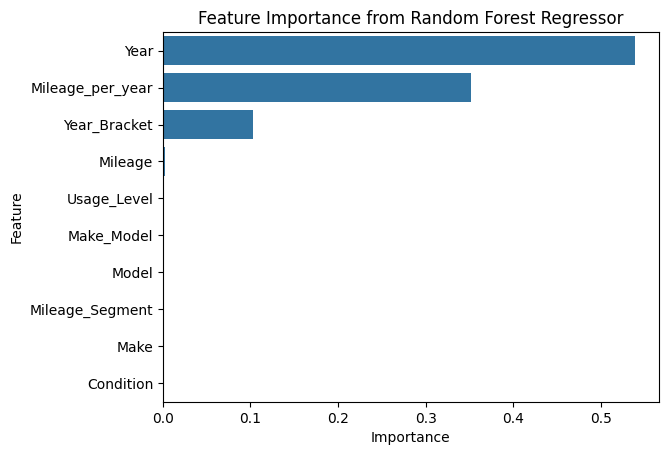

In [81]:
# barplot to show feature importance
sns.barplot(x="Importance", y="Feature", data=feature_importance)
plt.title("Feature Importance from Random Forest Regressor")
plt.show()